<a href="https://colab.research.google.com/github/tomeravgil/Homework5CSCI6170/blob/main/Homework5_Task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 1

## Part 1

**Dataset:** [Intel Image Classification](https://www.kaggle.com/datasets/puneet6060/intel-image-classification)  
**Task:** Multi-class image classification across 6 scene categories  
**Classes:** `buildings`, `forest`, `glacier`, `mountain`, `sea`, `street`

In [1]:
!pip install kaggle

!kaggle datasets download -d puneet6060/intel-image-classification
!unzip -q intel-image-classification.zip -d intel_data

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:01<00:00, 233MB/s]



In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
TRAIN_DIR = "intel_data/seg_train/seg_train"
TEST_DIR  = "intel_data/seg_test/seg_test"

IMG_SIZE  = 150
BATCH     = 32
NUM_WORKERS = 8

CLASSES = sorted(os.listdir(TRAIN_DIR))
print("Classes:", CLASSES)

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [16]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

full_train = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
test_ds    = datasets.ImageFolder(TEST_DIR,  transform=eval_transform)

# Hold out 15 % of training data as validation set
val_size   = int(0.15 * len(full_train))
train_size = len(full_train) - val_size
train_ds, val_ds = random_split(full_train, [train_size, val_size],
                                generator=torch.Generator().manual_seed(SEED))

# Apply eval transform to the validation split
val_ds.dataset = datasets.ImageFolder(TRAIN_DIR, transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
valid_loader = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train samples : {train_size}")
print(f"Val   samples : {val_size}")
print(f"Test  samples : {len(test_ds)}")
print(f"Class → index : {full_train.class_to_idx}")

Train samples : 11929
Val   samples : 2105
Test  samples : 3000
Class → index : {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


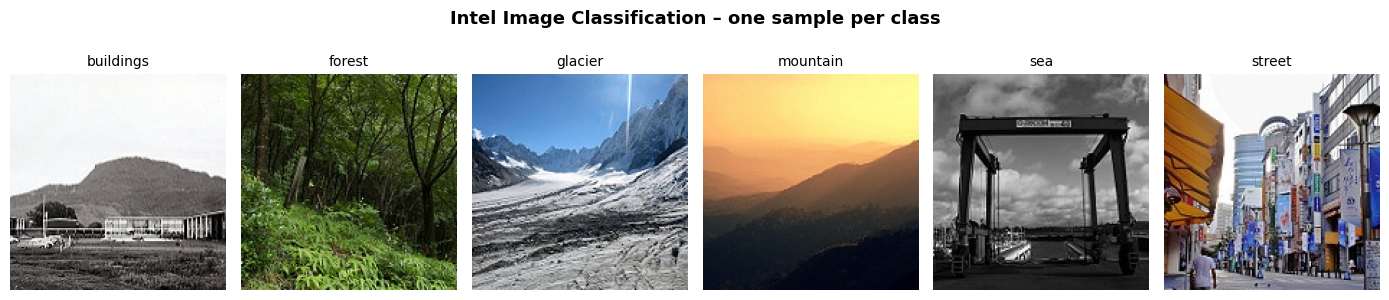

In [5]:
display_ds = datasets.ImageFolder(TRAIN_DIR,
                                  transform=transforms.Compose([
                                      transforms.Resize((IMG_SIZE, IMG_SIZE)),
                                      transforms.ToTensor()
                                  ]))

class_examples = {}
for img, label in display_ds:
    if label not in class_examples:
        class_examples[label] = img
    if len(class_examples) == len(CLASSES):
        break

fig, axes = plt.subplots(1, len(CLASSES), figsize=(14, 3))
fig.suptitle("Intel Image Classification – one sample per class",
             fontsize=13, fontweight='bold', y=1.02)

for idx, cls in enumerate(CLASSES):
    img = class_examples[display_ds.class_to_idx[cls]].permute(1, 2, 0).numpy()
    axes[idx].imshow(img)
    axes[idx].set_title(cls, fontsize=10)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig("samples_per_class.png", dpi=120, bbox_inches='tight')
plt.show()

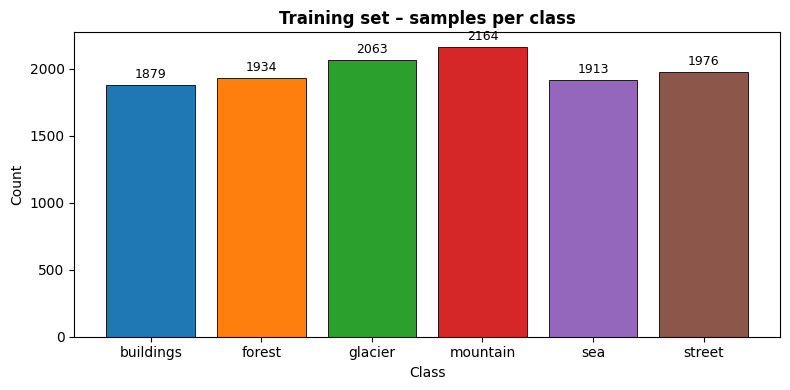

Trainable parameters: 1,572,646
CNN(
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (block4): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, trac

In [6]:
from collections import Counter

train_labels = [full_train.targets[i] for i in train_ds.indices]
counts = Counter(train_labels)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar([CLASSES[k] for k in sorted(counts)],
              [counts[k] for k in sorted(counts)],
              color=plt.cm.tab10.colors[:len(CLASSES)], edgecolor='black', linewidth=0.6)
ax.set_title("Training set – samples per class", fontsize=12, fontweight='bold')
ax.set_xlabel("Class")
ax.set_ylabel("Count")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=120, bbox_inches='tight')
plt.show()

def evaluate(loader, model):
    """Returns accuracy (fraction correct) on the given DataLoader."""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            preds = torch.argmax(model(images), dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return correct / total


class CNN(nn.Module):
    def _conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def __init__(self, num_classes=6):
        super().__init__()
        self.pool = nn.MaxPool2d(2, 2)

        self.block1 = self._conv_block(3,   32)
        self.block2 = self._conv_block(32,  64)
        self.block3 = self._conv_block(64,  128)
        self.block4 = self._conv_block(128, 256)
        self.block5 = self._conv_block(256, 512)

        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.5)
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(self.block1(x))
        x = self.pool(self.block2(x))
        x = self.pool(self.block3(x))
        x = self.pool(self.block4(x))
        x = self.pool(self.block5(x))
        x = self.global_avg_pool(x)
        x = torch.flatten(x, 1)        # (B, 512)
        x = self.dropout(x)
        return self.classifier(x)


model = CNN(num_classes=6).to(device)

# Quick parameter count
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")
print(model)



In [8]:
# ── Loss, Optimiser, Scheduler ────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)   # slight smoothing aids generalisation

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

# Reduce LR by half when validation loss stagnates
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

# ── Training loop ─────────────────────────────────────────────────────────
NUM_EPOCHS  = 50
PATIENCE    = 10          # early-stop after this many epochs w/o improvement
BEST_MODEL  = "best_model_intel.pth"

best_val_acc  = 0.0
no_improve    = 0

train_losses, val_losses       = [], []
train_accs,   val_accs         = [], []

for epoch in range(NUM_EPOCHS):
    # ── Train ──
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()

    # ── Compute epoch losses ──
    model.eval()
    t_loss = v_loss = 0.0
    with torch.no_grad():
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            t_loss += criterion(model(imgs), lbls).item()
        for imgs, lbls in valid_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            v_loss += criterion(model(imgs), lbls).item()

    t_loss /= len(train_loader)
    v_loss /= len(valid_loader)
    scheduler.step(v_loss)

    t_acc = evaluate(train_loader, model)
    v_acc = evaluate(valid_loader, model)

    train_losses.append(t_loss);  val_losses.append(v_loss)
    train_accs.append(t_acc);     val_accs.append(v_acc)

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        no_improve   = 0
        torch.save(model.state_dict(), BEST_MODEL)
        print(f"★ Epoch {epoch+1:02d} | TrainLoss {t_loss:.4f} | "
              f"ValLoss {v_loss:.4f} | TrainAcc {t_acc:.4f} | ValAcc {v_acc:.4f}")
    else:
        no_improve += 1
        print(f"  Epoch {epoch+1:02d} | TrainLoss {t_loss:.4f} | "
              f"ValLoss {v_loss:.4f} | TrainAcc {t_acc:.4f} | ValAcc {v_acc:.4f} "
              f"[no improve {no_improve}/{PATIENCE}]")
        if no_improve >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}.")
            break

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

★ Epoch 01 | TrainLoss 1.0941 | ValLoss 1.1173 | TrainAcc 0.6892 | ValAcc 0.6808
★ Epoch 02 | TrainLoss 1.2611 | ValLoss 1.1272 | TrainAcc 0.6383 | ValAcc 0.6955
★ Epoch 03 | TrainLoss 0.8845 | ValLoss 0.8978 | TrainAcc 0.7980 | ValAcc 0.7905
  Epoch 04 | TrainLoss 0.8757 | ValLoss 0.8998 | TrainAcc 0.7980 | ValAcc 0.7853 [no improve 1/10]
★ Epoch 05 | TrainLoss 0.7527 | ValLoss 0.7603 | TrainAcc 0.8593 | ValAcc 0.8556
  Epoch 06 | TrainLoss 0.8014 | ValLoss 0.7979 | TrainAcc 0.8263 | ValAcc 0.8342 [no improve 1/10]
★ Epoch 07 | TrainLoss 0.7273 | ValLoss 0.7294 | TrainAcc 0.8676 | ValAcc 0.8632
  Epoch 08 | TrainLoss 0.7404 | ValLoss 0.7833 | TrainAcc 0.8613 | ValAcc 0.8442 [no improve 1/10]
  Epoch 09 | TrainLoss 0.7429 | ValLoss 0.7462 | TrainAcc 0.8587 | ValAcc 0.8542 [no improve 2/10]
★ Epoch 10 | TrainLoss 0.7359 | ValLoss 0.7321 | TrainAcc 0.8663 | ValAcc 0.8656
  Epoch 11 | TrainLoss 0.7461 | ValLoss 0.7474 | TrainAcc 0.8590 | ValAcc 0.8584 [no improve 1/10]
★ Epoch 12 | TrainL

In [9]:
model.load_state_dict(torch.load(BEST_MODEL, map_location=device))
model.eval()

test_acc = evaluate(test_loader, model)
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f} %)")

Test Accuracy: 0.9197 (91.97 %)


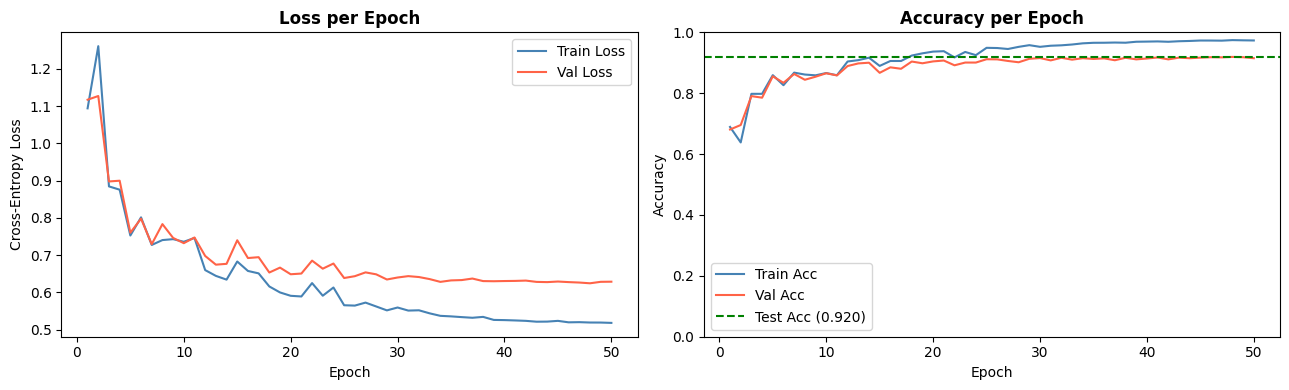

              precision    recall  f1-score   support

   buildings     0.9176    0.9176    0.9176       437
      forest     0.9791    0.9895    0.9843       474
     glacier     0.9002    0.8644    0.8819       553
    mountain     0.8609    0.8838    0.8722       525
         sea     0.9294    0.9549    0.9420       510
      street     0.9388    0.9182    0.9284       501

    accuracy                         0.9197      3000
   macro avg     0.9210    0.9214    0.9211      3000
weighted avg     0.9197    0.9197    0.9195      3000



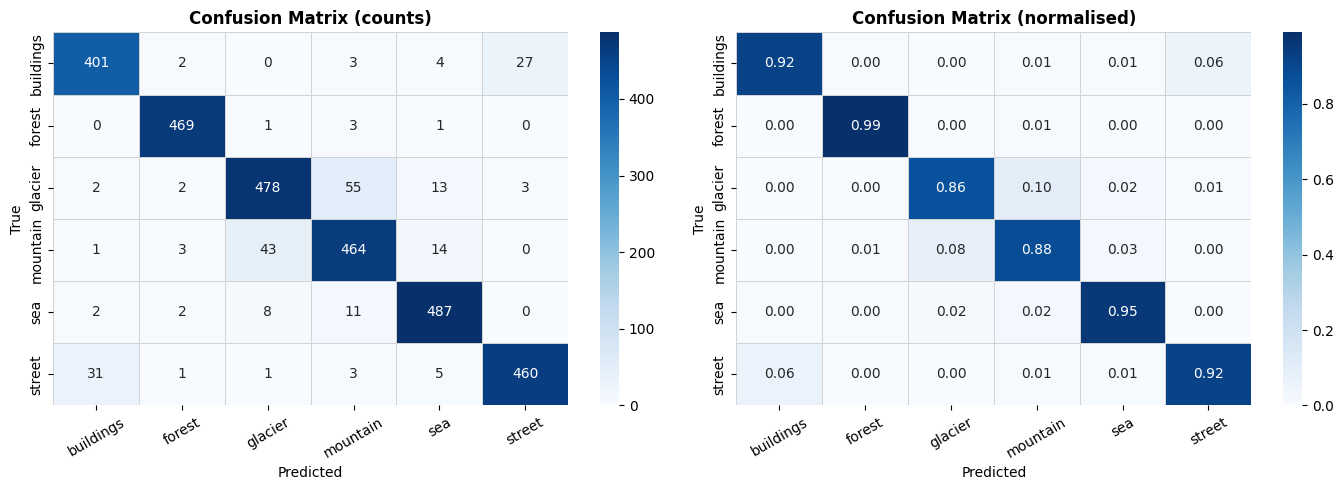

In [10]:
epochs_ran = range(1, len(train_losses) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(epochs_ran, train_losses, label='Train Loss', color='steelblue')
ax1.plot(epochs_ran, val_losses,   label='Val Loss',   color='tomato')
ax1.set_title("Loss per Epoch", fontweight='bold')
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Cross-Entropy Loss")
ax1.legend()

ax2.plot(epochs_ran, train_accs, label='Train Acc', color='steelblue')
ax2.plot(epochs_ran, val_accs,   label='Val Acc',   color='tomato')
ax2.axhline(test_acc, linestyle='--', color='green', label=f'Test Acc ({test_acc:.3f})')
ax2.set_title("Accuracy per Epoch", fontweight='bold')
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1)
ax2.legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120, bbox_inches='tight')
plt.show()

all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        preds = torch.argmax(model(imgs), dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(lbls.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASSES, digits=4))

cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, fmt, title in zip(
        axes,
        [cm, cm_norm],
        ['d', '.2f'],
        ['Confusion Matrix (counts)', 'Confusion Matrix (normalised)']):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
                linewidths=0.4, linecolor='lightgrey')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120, bbox_inches='tight')
plt.show()

## Results

Overall, we see a very balanced dataset and testing was very inline with our validation set, but we do see a bit of overfitting between training and validation with 97.33% training accuracy compared to 91.5% validation accuracy. Given a testing accuracy of 91.97%, this is inline with other models as well on this dataset. This could have been prevented a bit more by reducing the patience to a number lower than 5 so if there was repetition or very minimal changes in training we would stop and overfitting wouldn't have been as severe. We do see that the model was able to stabilize based on the slopes at the later epochs stabilizing between loss and accuracy. Precision, Recall, and F1-score are all very balanced, but we do see a bit of mispredictions between streets and buildings as well as glaciers and mountains and this is mainly to do with the feature curves of mountains and glaciers being very similar as well with building images including steets as well.

## Architecture Decisions

Training was done with regularization techniques with weight decay, early stopping, and a scheduler to. reduce learning rate on a plateau to make sure we still learn and don't stop too early. The CNN was build with 5 maxpooling layers and convolution layers, with batch normalization, reLU, and dropout. reLU was chosen for faster training, dropout was used for strengthening nodes that weren't being selected/had lower weights and batch normalization was used as a technique for faster training and also reduces overfitting as well. Adaptive average pooling was used to collapse the feature map from a 8,192 feature vector to 512 features to also reduce overfitting. 5 convolutional blocks were used to compensate for lost resolution with depth and usually works well with natural scene classification where hierarchical features make or break the model. There were transformations applied to the dataset for training with random horizontal flipping, rotation, and color. This leads to less underfitting and allows the model to get better prediction as some classes are similar to one another.

## Part 2

In [17]:
from torchvision import models

# ── Transforms (must be defined before datasets) ──────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# ── Datasets & Loaders ────────────────────────────────────────────────────
full_train = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
test_ds    = datasets.ImageFolder(TEST_DIR,  transform=eval_transform)

val_size   = int(0.15 * len(full_train))
train_size = len(full_train) - val_size
train_ds_224, val_ds = random_split(full_train, [train_size, val_size],
                                generator=torch.Generator().manual_seed(SEED))
val_ds.dataset = datasets.ImageFolder(TRAIN_DIR, transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
valid_loader = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader_224  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

In [14]:


# ── Model ─────────────────────────────────────────────────────────────────
transfer_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

for param in transfer_model.parameters():
    param.requires_grad = False

for param in transfer_model.layer4.parameters():
    param.requires_grad = True



transfer_model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(transfer_model.fc.in_features, 6)
)

transfer_model = transfer_model.to(device)

total_params = sum(p.numel() for p in transfer_model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

# ── Loss, Optimizer, Scheduler ────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Use a lower LR for the conv layers to avoid destroying pretrained weights
optimizer = torch.optim.Adam([
    {'params': transfer_model.layer4.parameters(), 'lr': 1e-4},
    {'params': transfer_model.fc.parameters(),     'lr': 1e-3},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)



# ── Training Loop ─────────────────────────────────────────────────────────
NUM_EPOCHS = 50
PATIENCE   = 10
BEST_MODEL = "best_model_resnet.pth"

best_val_acc = 0.0
no_improve   = 0

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(NUM_EPOCHS):
    transfer_model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(transfer_model(images), labels)
        loss.backward()
        optimizer.step()

    transfer_model.eval()
    t_loss = v_loss = 0.0
    with torch.no_grad():
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            t_loss += criterion(transfer_model(imgs), lbls).item()
        for imgs, lbls in valid_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            v_loss += criterion(transfer_model(imgs), lbls).item()

    t_loss /= len(train_loader)
    v_loss /= len(valid_loader)
    scheduler.step(v_loss)

    t_acc = evaluate(train_loader, transfer_model)
    v_acc = evaluate(valid_loader, transfer_model)

    train_losses.append(t_loss); val_losses.append(v_loss)
    train_accs.append(t_acc);    val_accs.append(v_acc)

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        no_improve   = 0
        torch.save(transfer_model.state_dict(), BEST_MODEL)
        print(f"★ Epoch {epoch+1:02d} | TrainLoss {t_loss:.4f} | "
              f"ValLoss {v_loss:.4f} | TrainAcc {t_acc:.4f} | ValAcc {v_acc:.4f}")
    else:
        no_improve += 1
        print(f"  Epoch {epoch+1:02d} | TrainLoss {t_loss:.4f} | "
              f"ValLoss {v_loss:.4f} | TrainAcc {t_acc:.4f} | ValAcc {v_acc:.4f} "
              f"[no improve {no_improve}/{PATIENCE}]")
        if no_improve >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}.")
            break

print(f"\nBest validation accuracy: {best_val_acc:.4f}")



Trainable parameters: 14,977,030
★ Epoch 01 | TrainLoss 0.5641 | ValLoss 0.6079 | TrainAcc 0.9475 | ValAcc 0.9278
  Epoch 02 | TrainLoss 0.5380 | ValLoss 0.5968 | TrainAcc 0.9591 | ValAcc 0.9235 [no improve 1/10]
★ Epoch 03 | TrainLoss 0.5226 | ValLoss 0.6097 | TrainAcc 0.9642 | ValAcc 0.9292
★ Epoch 04 | TrainLoss 0.4985 | ValLoss 0.5914 | TrainAcc 0.9743 | ValAcc 0.9349
★ Epoch 05 | TrainLoss 0.4869 | ValLoss 0.5840 | TrainAcc 0.9808 | ValAcc 0.9416
  Epoch 06 | TrainLoss 0.4763 | ValLoss 0.5866 | TrainAcc 0.9879 | ValAcc 0.9373 [no improve 1/10]
  Epoch 07 | TrainLoss 0.4635 | ValLoss 0.5841 | TrainAcc 0.9918 | ValAcc 0.9330 [no improve 2/10]
  Epoch 08 | TrainLoss 0.4691 | ValLoss 0.5916 | TrainAcc 0.9928 | ValAcc 0.9283 [no improve 3/10]
  Epoch 09 | TrainLoss 0.4574 | ValLoss 0.6005 | TrainAcc 0.9951 | ValAcc 0.9349 [no improve 4/10]
★ Epoch 10 | TrainLoss 0.4396 | ValLoss 0.5646 | TrainAcc 0.9971 | ValAcc 0.9458
  Epoch 11 | TrainLoss 0.4341 | ValLoss 0.5646 | TrainAcc 0.9982 | 

In [19]:
# ── Final Evaluation ──────────────────────────────────────────────────────
transfer_model.load_state_dict(torch.load(BEST_MODEL, map_location=device))

scratch_acc  = evaluate(test_loader, model)
transfer_acc = evaluate(test_loader_224, transfer_model)

print(f"{'Model':<25} {'Test Accuracy':>15}")
print("-" * 42)
print(f"{'CNN from scratch':<25} {scratch_acc*100:>14.2f}%")
print(f"{'ResNet50 (frozen)':<25} {transfer_acc*100:>14.2f}%")

Model                       Test Accuracy
------------------------------------------
CNN from scratch                   91.97%
ResNet50 (frozen)                  93.50%


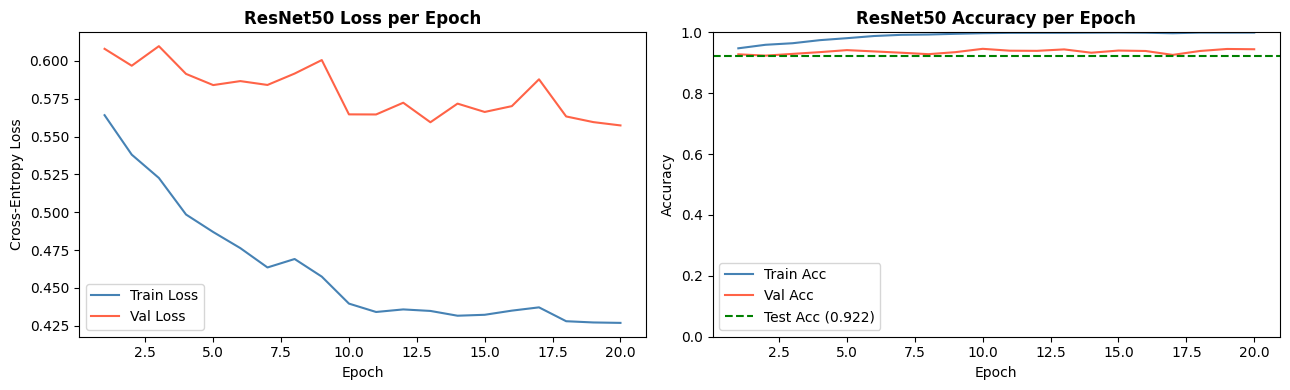

              precision    recall  f1-score   support

   buildings     0.8858    0.9405    0.9123       437
      forest     0.9937    0.9958    0.9947       474
     glacier     0.8687    0.8969    0.8826       553
    mountain     0.9083    0.8114    0.8571       525
         sea     0.9360    0.9745    0.9549       510
      street     0.9449    0.9242    0.9344       501

    accuracy                         0.9217      3000
   macro avg     0.9229    0.9239    0.9227      3000
weighted avg     0.9220    0.9217    0.9211      3000



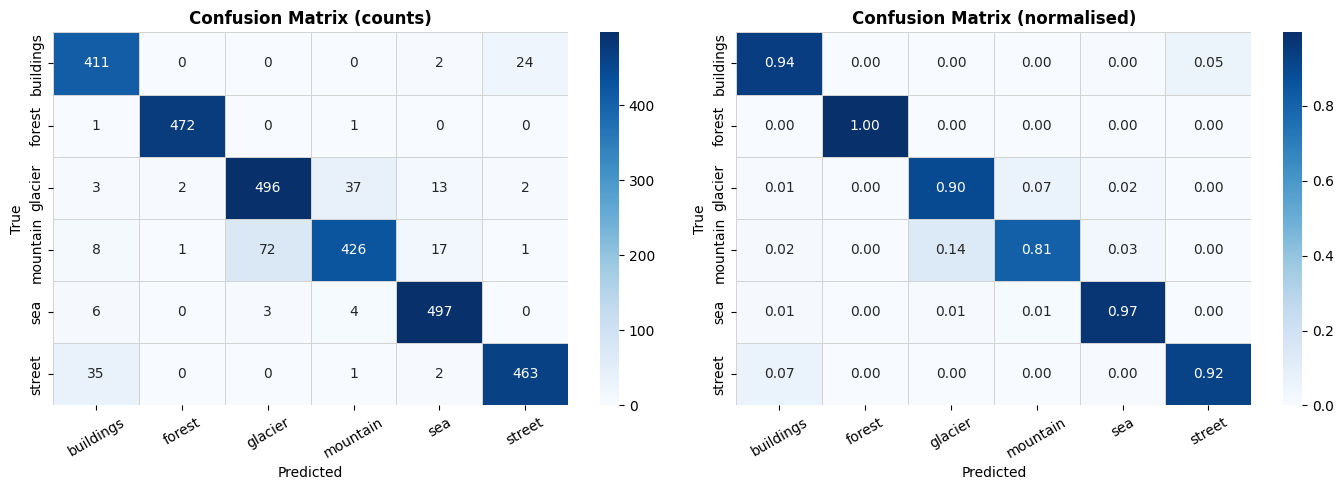

In [21]:
transfer_acc = evaluate(test_loader, transfer_model)

epochs_ran = range(1, len(train_losses) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(epochs_ran, train_losses, label='Train Loss', color='steelblue')
ax1.plot(epochs_ran, val_losses,   label='Val Loss',   color='tomato')
ax1.set_title("ResNet50 Loss per Epoch", fontweight='bold')
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Cross-Entropy Loss")
ax1.legend()

ax2.plot(epochs_ran, train_accs, label='Train Acc', color='steelblue')
ax2.plot(epochs_ran, val_accs,   label='Val Acc',   color='tomato')
ax2.axhline(transfer_acc, linestyle='--', color='green', label=f'Test Acc ({transfer_acc:.3f})')
ax2.set_title("ResNet50 Accuracy per Epoch", fontweight='bold')
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1)
ax2.legend()

plt.tight_layout()
plt.show()

all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        preds = torch.argmax(transfer_model(imgs), dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(lbls.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASSES, digits=4))

cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, fmt, title in zip(
        axes,
        [cm, cm_norm],
        ['d', '.2f'],
        ['Confusion Matrix (counts)', 'Confusion Matrix (normalised)']):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
                linewidths=0.4, linecolor='lightgrey')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## Differences in Training

Overall, we see there is a better test accuracy (93.5%) and less overfitting with ResNet50, but. there were big changes in image size as we needed to fit the model to 224px to satisfy the model architecture for resnet. As well, comparitive to resnet, we were able with our custom model to make an architecture direct to our training and test images. Since ResNet is already pretrained, therefore it did not take as many epochs and triggered early stopping around epoch 20 while our from scratch model took all 50 epochs. As well, we do see a decrease in precision in some categories like buildings and glaciers, but overall a better marro average in all 3 categories as well as weighted average.

## Part 3

Since transformations were added in part 1 + part 2, part 3 will compare without transformations.

In [22]:
TRAIN_DIR = "intel_data/seg_train/seg_train"
TEST_DIR  = "intel_data/seg_test/seg_test"

IMG_SIZE  = 150
BATCH     = 32
NUM_WORKERS = 8

CLASSES = sorted(os.listdir(TRAIN_DIR))
print("Classes:", CLASSES)

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

full_train = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
test_ds    = datasets.ImageFolder(TEST_DIR,  transform=eval_transform)

val_size   = int(0.15 * len(full_train))
train_size = len(full_train) - val_size
train_ds, val_ds = random_split(full_train, [train_size, val_size],
                                generator=torch.Generator().manual_seed(SEED))

val_ds.dataset = datasets.ImageFolder(TRAIN_DIR, transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
valid_loader = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train samples : {train_size}")
print(f"Val   samples : {val_size}")
print(f"Test  samples : {len(test_ds)}")
print(f"Class → index : {full_train.class_to_idx}")

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Train samples : 11929
Val   samples : 2105
Test  samples : 3000
Class → index : {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


In [23]:
model = CNN(num_classes=6).to(device)

# ── Loss, Optimiser, Scheduler ────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)   # slight smoothing aids generalisation

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

# Reduce LR by half when validation loss stagnates
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

# ── Training loop ─────────────────────────────────────────────────────────
NUM_EPOCHS  = 50
PATIENCE    = 10          # early-stop after this many epochs w/o improvement
BEST_MODEL  = "best_model_intel_no_transform.pth"

best_val_acc  = 0.0
no_improve    = 0

train_losses, val_losses       = [], []
train_accs,   val_accs         = [], []

for epoch in range(NUM_EPOCHS):
    # ── Train ──
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()

    # ── Compute epoch losses ──
    model.eval()
    t_loss = v_loss = 0.0
    with torch.no_grad():
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            t_loss += criterion(model(imgs), lbls).item()
        for imgs, lbls in valid_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            v_loss += criterion(model(imgs), lbls).item()

    t_loss /= len(train_loader)
    v_loss /= len(valid_loader)
    scheduler.step(v_loss)

    t_acc = evaluate(train_loader, model)
    v_acc = evaluate(valid_loader, model)

    train_losses.append(t_loss);  val_losses.append(v_loss)
    train_accs.append(t_acc);     val_accs.append(v_acc)

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        no_improve   = 0
        torch.save(model.state_dict(), BEST_MODEL)
        print(f"★ Epoch {epoch+1:02d} | TrainLoss {t_loss:.4f} | "
              f"ValLoss {v_loss:.4f} | TrainAcc {t_acc:.4f} | ValAcc {v_acc:.4f}")
    else:
        no_improve += 1
        print(f"  Epoch {epoch+1:02d} | TrainLoss {t_loss:.4f} | "
              f"ValLoss {v_loss:.4f} | TrainAcc {t_acc:.4f} | ValAcc {v_acc:.4f} "
              f"[no improve {no_improve}/{PATIENCE}]")
        if no_improve >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}.")
            break

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

★ Epoch 01 | TrainLoss 0.9505 | ValLoss 0.9916 | TrainAcc 0.7545 | ValAcc 0.7302
★ Epoch 02 | TrainLoss 0.9420 | ValLoss 0.9674 | TrainAcc 0.7683 | ValAcc 0.7439
★ Epoch 03 | TrainLoss 0.7658 | ValLoss 0.7940 | TrainAcc 0.8515 | ValAcc 0.8375
★ Epoch 04 | TrainLoss 0.7372 | ValLoss 0.7730 | TrainAcc 0.8668 | ValAcc 0.8423
  Epoch 05 | TrainLoss 0.7697 | ValLoss 0.8171 | TrainAcc 0.8401 | ValAcc 0.8166 [no improve 1/10]
★ Epoch 06 | TrainLoss 0.7111 | ValLoss 0.7569 | TrainAcc 0.8760 | ValAcc 0.8527
  Epoch 07 | TrainLoss 0.7314 | ValLoss 0.8070 | TrainAcc 0.8692 | ValAcc 0.8352 [no improve 1/10]
★ Epoch 08 | TrainLoss 0.6910 | ValLoss 0.7511 | TrainAcc 0.8893 | ValAcc 0.8599
  Epoch 09 | TrainLoss 0.6828 | ValLoss 0.7590 | TrainAcc 0.8905 | ValAcc 0.8556 [no improve 1/10]
  Epoch 10 | TrainLoss 0.7218 | ValLoss 0.7909 | TrainAcc 0.8754 | ValAcc 0.8527 [no improve 2/10]
  Epoch 11 | TrainLoss 0.6939 | ValLoss 0.7876 | TrainAcc 0.8830 | ValAcc 0.8385 [no improve 3/10]
★ Epoch 12 | TrainL

In [24]:
model.load_state_dict(torch.load(BEST_MODEL, map_location=device))
model.eval()

test_acc = evaluate(test_loader, model)
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f} %)")

Test Accuracy: 0.9003 (90.03 %)


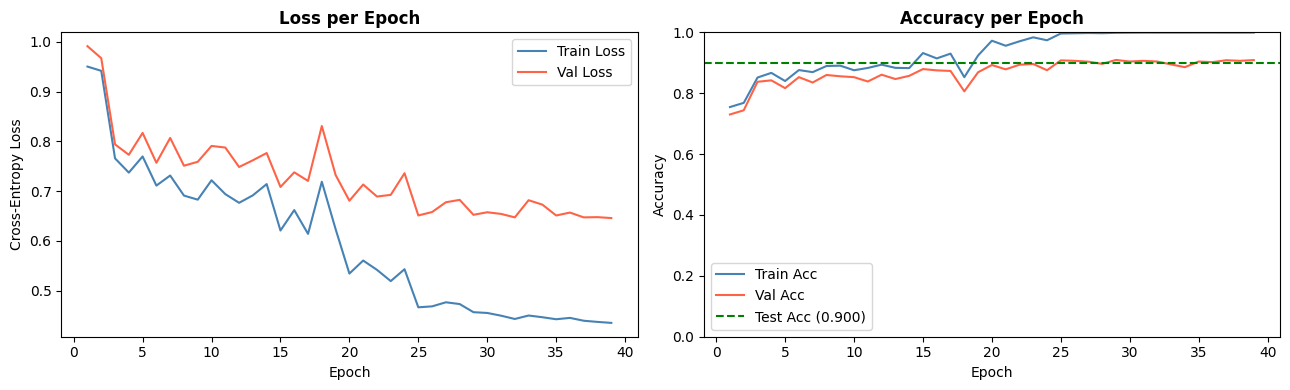

              precision    recall  f1-score   support

   buildings     0.8854    0.9016    0.8934       437
      forest     0.9609    0.9852    0.9729       474
     glacier     0.9156    0.8047    0.8566       553
    mountain     0.8450    0.8724    0.8585       525
         sea     0.8746    0.9569    0.9139       510
      street     0.9296    0.8962    0.9126       501

    accuracy                         0.9003      3000
   macro avg     0.9019    0.9028    0.9013      3000
weighted avg     0.9014    0.9003    0.8998      3000



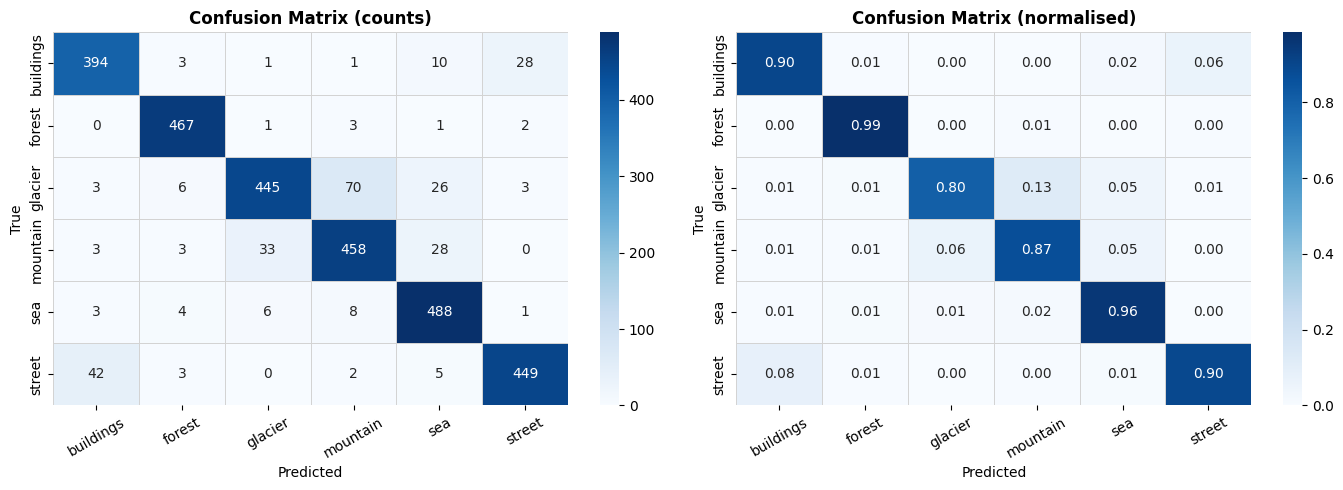

In [25]:
epochs_ran = range(1, len(train_losses) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(epochs_ran, train_losses, label='Train Loss', color='steelblue')
ax1.plot(epochs_ran, val_losses,   label='Val Loss',   color='tomato')
ax1.set_title("Loss per Epoch", fontweight='bold')
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Cross-Entropy Loss")
ax1.legend()

ax2.plot(epochs_ran, train_accs, label='Train Acc', color='steelblue')
ax2.plot(epochs_ran, val_accs,   label='Val Acc',   color='tomato')
ax2.axhline(test_acc, linestyle='--', color='green', label=f'Test Acc ({test_acc:.3f})')
ax2.set_title("Accuracy per Epoch", fontweight='bold')
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1)
ax2.legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120, bbox_inches='tight')
plt.show()

all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        preds = torch.argmax(model(imgs), dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(lbls.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASSES, digits=4))

cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, fmt, title in zip(
        axes,
        [cm, cm_norm],
        ['d', '.2f'],
        ['Confusion Matrix (counts)', 'Confusion Matrix (normalised)']):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
                linewidths=0.4, linecolor='lightgrey')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120, bbox_inches='tight')
plt.show()

## Differences with and without Transformations

Given the results side by side, the most noteable differences between training w/ transformations and without transformations is the overfitting between training accuracy which is about 99% while the validation accuracy is stabilized around 90%. We can also see this in loss and also between the accuracy over epochs graph. With transformations, our training accuracy is at around 97% while our validation is at around 92% giving about a 5% difference in accuracy comparative to 9%. This shows that tranformations lead to a decrease in overfitting. The reason for this is since transformations are random, it adds an ability for the model to see the same data point in different ways which also allows for the model to generalize, but not memorize. Given this, there is a reduction in overfitting.